# 01 — Data Loading & Exploratory Analysis

First pass over the DOL disclosure data, now spanning full FY2025 plus FY2026 through Q3:
- LCA (H-1B/E-3/H-1B1) Labor Condition Applications
- PERM labor certifications (green card sponsorship)

Raw sources arrive inconsistently (one cumulative CSV for FY2026, four separate quarterly
XLSX exports for FY2025) — `src/consolidate_raw.py` normalizes all of that into
`data/interim/{lca,perm}_master.csv` once, tagged with a derived `FISCAL_YEAR`/`FISCAL_QUARTER`.
Run `python src/consolidate_raw.py` after dropping new raw exports into `data/raw/` to rebuild
those before running this notebook.

Goal here is just to understand shape, quality, and headline distributions (now with a
year-over-year lens) before we narrow in on MBA-relevant roles in notebook 02.

**Note on a fixed data bug**: one source file (`LCA_Disclosure_Data_FY2025_Q2.xlsx`, ~13% of
LCA data) exported nearly every text cell wrapped as a literal Excel "keep as text" string
(`="541511"` instead of `541511`), which silently corrupted `SOC_CODE` for that whole quarter
and broke MBA-tier classification for those rows. `consolidate_raw.py` now strips this on
ingestion — if you're comparing against an earlier run of this notebook, the FY2025 numbers
(and anything YoY) will have shifted slightly as a result.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data_loader import load_lca, load_perm, annual_wage  # noqa: E402
from employer_canonicalization import add_canonical_employer  # noqa: E402

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
FIG_DIR = Path.cwd().parent / "outputs" / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load both consolidated master files

In [2]:
lca = load_lca()
perm = load_perm()

print(f"LCA (H-1B/E-3/H-1B1) records: {len(lca):,}")
print(f"PERM records: {len(perm):,}")

LCA (H-1B/E-3/H-1B1) records: 1,023,639
PERM records: 259,489


### Coverage by fiscal year/quarter

Fiscal year and quarter are derived from `DECISION_DATE` (falling back to `RECEIVED_DATE` for
undecided cases) using the federal fiscal calendar, not trusted from source filenames — DOL's
own file naming isn't a reliable signal (a "FY2026 Q3" file can be a Q1-Q3 cumulative export).

In [3]:
lca.groupby(["FISCAL_YEAR", "FISCAL_QUARTER"]).size().unstack(fill_value=0)

FISCAL_QUARTER,1,2,3,4
FISCAL_YEAR,,,,
2025,104426,129790,235233,116694
2026,82950,122739,231807,0


In [4]:
perm.groupby(["FISCAL_YEAR", "FISCAL_QUARTER"]).size().unstack(fill_value=0)

FISCAL_QUARTER,1,2,3,4
FISCAL_YEAR,,,,
2025,24364,34195,42444,45936
2026,18109,41840,52601,0


## Employer name canonicalization

Raw employer names are fragmented by casing/punctuation/legal-suffix noise — e.g. "Hire IT
People, Inc" / "Hire IT People, Inc." / "HIRE IT PEOPLE INC" all show up as different strings
for the same employer, which understates their true filing volume in any employer-level
ranking. `add_canonical_employer` (see `src/employer_canonicalization.py`) collapses these
safely — it does *not* attempt to merge distinct legal subsidiaries under one brand (e.g.
"Amazon Web Services, Inc." vs "Amazon.com Services LLC" stay separate), since that's a
harder problem where naive matching produces false merges (a real risk here: "Apple American
Group LLC" is an Applebee's franchisee, not Apple Inc.).

In [5]:
lca_raw_employers = lca["EMPLOYER_NAME"].nunique()
lca = add_canonical_employer(lca, "EMPLOYER_NAME", "EMPLOYER_CANONICAL")
perm_raw_employers = perm["EMP_BUSINESS_NAME"].nunique()
perm = add_canonical_employer(perm, "EMP_BUSINESS_NAME", "EMPLOYER_CANONICAL")

print(f"LCA employers: {lca_raw_employers:,} raw names -> {lca['EMPLOYER_CANONICAL'].nunique():,} canonical")
print(f"PERM employers: {perm_raw_employers:,} raw names -> {perm['EMPLOYER_CANONICAL'].nunique():,} canonical")

LCA employers: 106,413 raw names -> 93,521 canonical
PERM employers: 60,842 raw names -> 56,064 canonical


In [6]:
lca.info()

<class 'pandas.DataFrame'>
RangeIndex: 1023639 entries, 0 to 1023638
Data columns (total 32 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   CASE_NUMBER             1023639 non-null  str           
 1   CASE_STATUS             1023639 non-null  str           
 2   RECEIVED_DATE           1023639 non-null  datetime64[us]
 3   DECISION_DATE           1023639 non-null  datetime64[us]
 4   VISA_CLASS              1023639 non-null  str           
 5   JOB_TITLE               1023639 non-null  str           
 6   SOC_CODE                1023639 non-null  str           
 7   SOC_TITLE               1023639 non-null  str           
 8   FULL_TIME_POSITION      1023639 non-null  str           
 9   TOTAL_WORKER_POSITIONS  1023639 non-null  int64         
 10  NEW_EMPLOYMENT          1023639 non-null  int64         
 11  CONTINUED_EMPLOYMENT    1023639 non-null  int64         
 12  CHANGE_EMPLOYER         1

In [7]:
perm.info()

<class 'pandas.DataFrame'>
RangeIndex: 259489 entries, 0 to 259488
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   CASE_NUMBER                    259489 non-null  str           
 1   CASE_STATUS                    259489 non-null  str           
 2   RECEIVED_DATE                  259489 non-null  datetime64[us]
 3   DECISION_DATE                  259489 non-null  datetime64[us]
 4   OCCUPATION_TYPE                259473 non-null  str           
 5   EMP_BUSINESS_NAME              259489 non-null  str           
 6   EMP_CITY                       259489 non-null  str           
 7   EMP_STATE                      259086 non-null  str           
 8   EMP_COUNTRY                    259483 non-null  str           
 9   EMP_NAICS                      259479 non-null  float64       
 10  EMP_NUM_PAYROLL                259470 non-null  float64       
 11  EMP_YEAR_CO

## Data quality: missingness

In [8]:
missing_lca = (lca.isna().mean() * 100).round(1).sort_values(ascending=False)
missing_lca[missing_lca > 0]

WAGE_RATE_OF_PAY_TO      81.7
PREVAILING_WAGE          42.7
WAGE_RATE_OF_PAY_FROM    42.7
WORKSITE_COUNTY           9.5
PW_WAGE_LEVEL             8.9
WILLFUL_VIOLATOR          2.3
H_1B_DEPENDENT            2.3
dtype: float64

In [9]:
missing_perm = (perm.isna().mean() * 100).round(1).sort_values(ascending=False)
missing_perm[missing_perm > 0]

JOB_OPP_WAGE_TO            68.9
PRIMARY_WORKSITE_COUNTY    58.3
JOB_OPP_WAGE_FROM          43.4
PRIMARY_WORKSITE_STATE      4.2
PRIMARY_WORKSITE_CITY       4.2
EMP_STATE                   0.2
PWD_SOC_CODE                0.1
PWD_SOC_TITLE               0.1
JOB_OPP_WAGE_PER            0.1
JOB_TITLE                   0.1
dtype: float64

## Case status: how often do filings actually get certified?

This is the headline number international students care about — of the cases DOL has
decided, what fraction were certified vs denied/withdrawn?

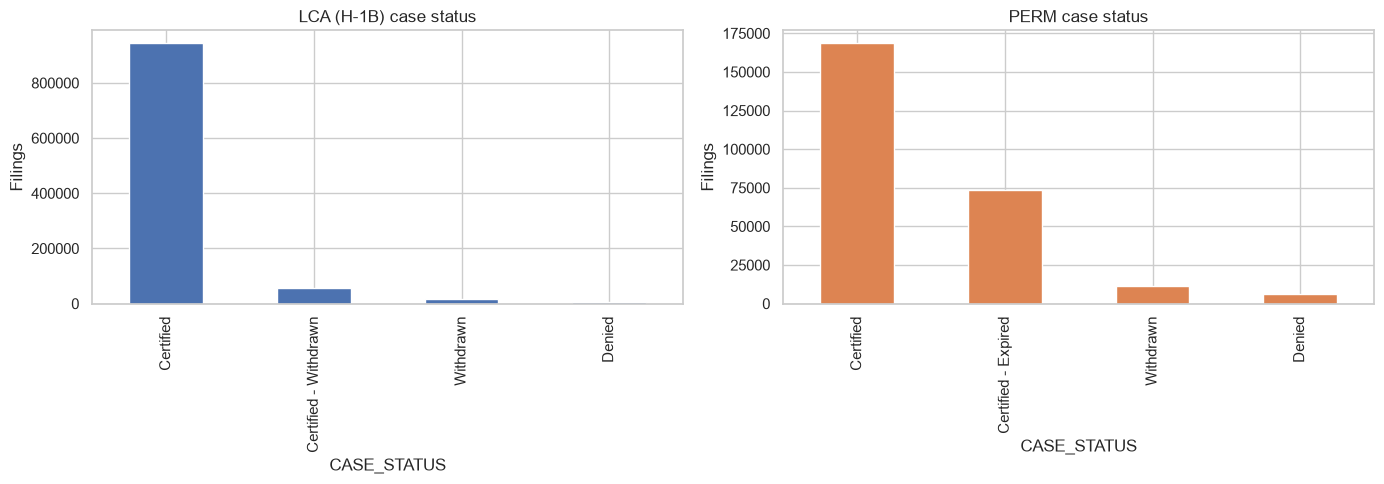

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lca["CASE_STATUS"].value_counts().plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("LCA (H-1B) case status")
axes[0].set_ylabel("Filings")

perm["CASE_STATUS"].value_counts(dropna=False).plot.bar(ax=axes[1], color="#DD8452")
axes[1].set_title("PERM case status")
axes[1].set_ylabel("Filings")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_case_status.png", dpi=150)
plt.show()

In [11]:
lca_decided = lca[lca["CASE_STATUS"].isin(["Certified", "Certified - Withdrawn", "Denied"])]
lca_cert_rate = (lca_decided["CASE_STATUS"] != "Denied").mean()
print(f"LCA certification rate (of decided cases): {lca_cert_rate:.1%}")

perm_decided = perm[perm["CASE_STATUS"].isin(["Certified", "Certified - Expired", "Denied"])]
perm_cert_rate = (perm_decided["CASE_STATUS"] != "Denied").mean()
print(f"PERM certification rate (of decided cases): {perm_cert_rate:.1%}")

LCA certification rate (of decided cases): 99.4%
PERM certification rate (of decided cases): 97.4%


LCA (H-1B) approval rates are famously high — the real bottleneck for H-1B is the annual
lottery/cap, which never shows up in this data at all (only *filed* LCAs, and most LCAs are
filed only after an employer already won a cap slot or the role is cap-exempt). PERM denial
rates, by contrast, are a more direct signal of employer/role risk since there's no lottery.

## Visa class breakdown (LCA)

In [12]:
lca["VISA_CLASS"].value_counts()

VISA_CLASS
H-1B               999239
E-3 Australian      17770
H-1B1 Chile          3854
H-1B1 Singapore      2776
Name: count, dtype: int64

## Top occupations by filing volume

In [13]:
top_soc_lca = lca["SOC_TITLE"].value_counts().head(20)
top_soc_lca

SOC_TITLE
Software Developers                                   307568
Computer Systems Engineers/Architects                  39686
Data Scientists                                        39011
Information Technology Project Managers                34753
Software Quality Assurance Analysts and Testers        33178
Computer Programmers                                   25399
Computer Systems Analysts                              22524
Computer and Information Systems Managers              22450
Business Intelligence Analysts                         21914
Mechanical Engineers                                   17328
Accountants and Auditors                               17007
Financial and Investment Analysts                      16789
Electronics Engineers, Except Computer                 14233
Operations Research Analysts                           13766
Electrical Engineers                                   13097
Management Analysts                                    12748
Database Admin

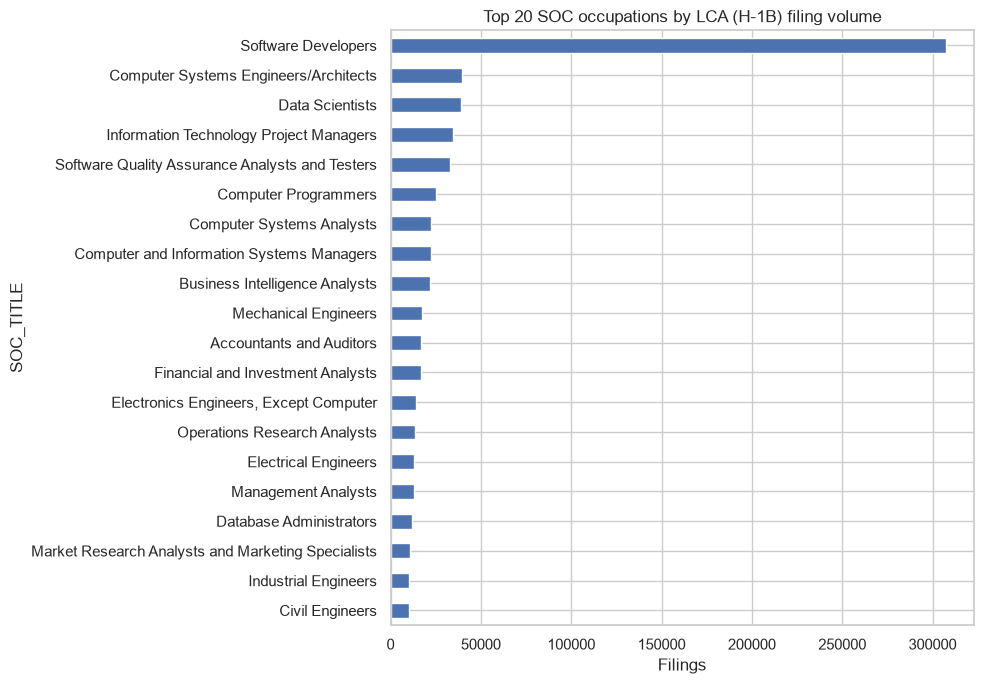

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))
top_soc_lca.sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_title("Top 20 SOC occupations by LCA (H-1B) filing volume")
ax.set_xlabel("Filings")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_top_soc_lca.png", dpi=150)
plt.show()

In [15]:
top_soc_perm = perm["PWD_SOC_TITLE"].value_counts().head(20)
top_soc_perm

PWD_SOC_TITLE
Software Developers                                57876
Computer Systems Analysts                          11592
Meat, Poultry, and Fish Cutters and Trimmers        8524
Fast Food and Counter Workers                       7119
Project Management Specialists                      6528
Data Scientists                                     5572
Software Quality Assurance Analysts and Testers     4691
Medical and Clinical Laboratory Technologists       4549
Landscaping and Groundskeeping Workers              4315
Nursing Assistants                                  3593
Computer and Information Systems Managers           3592
Accountants and Auditors                            3562
Electronics Engineers, Except Computer              3408
Helpers--Production Workers                         3110
Business Intelligence Analysts                      3018
Mechanical Engineers                                2880
Packers and Packagers, Hand                         2606
Team Assemblers  

## Filing volume over time

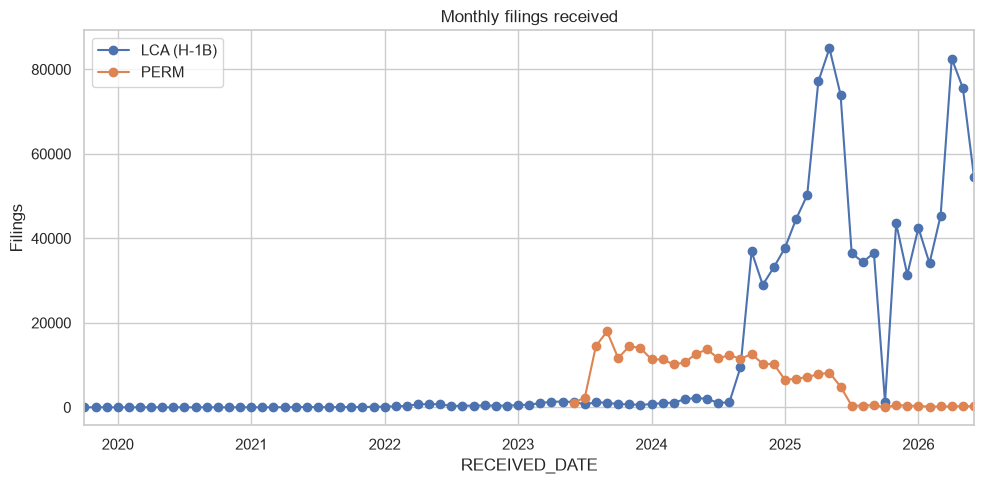

In [16]:
monthly_lca = lca.set_index("RECEIVED_DATE").resample("ME").size()
monthly_perm = perm.set_index("RECEIVED_DATE").resample("ME").size()

fig, ax = plt.subplots()
monthly_lca.plot(ax=ax, label="LCA (H-1B)", marker="o")
monthly_perm.plot(ax=ax, label="PERM", marker="o")
ax.set_title("Monthly filings received")
ax.set_ylabel("Filings")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "01_monthly_filings.png", dpi=150)
plt.show()

### Year-over-year: is sponsorship growing or shrinking?

FY2026 is partial (through Q3) — compare it to the *same* Q1-Q3 window in FY2025, not full-year
FY2025, or a shrinking year will look like growth just from missing Q4.


LCA (H-1B) — filings by quarter, FY2025 vs FY2026 (Q1-Q3 only):
FISCAL_YEAR       2025    2026
FISCAL_QUARTER                
1               104426   82950
2               129790  122739
3               235233  231807
FY2026 Q1-Q3 vs FY2025 Q1-Q3: -6.8%

PERM — filings by quarter, FY2025 vs FY2026 (Q1-Q3 only):
FISCAL_YEAR      2025   2026
FISCAL_QUARTER              
1               24364  18109
2               34195  41840
3               42444  52601
FY2026 Q1-Q3 vs FY2025 Q1-Q3: +11.4%


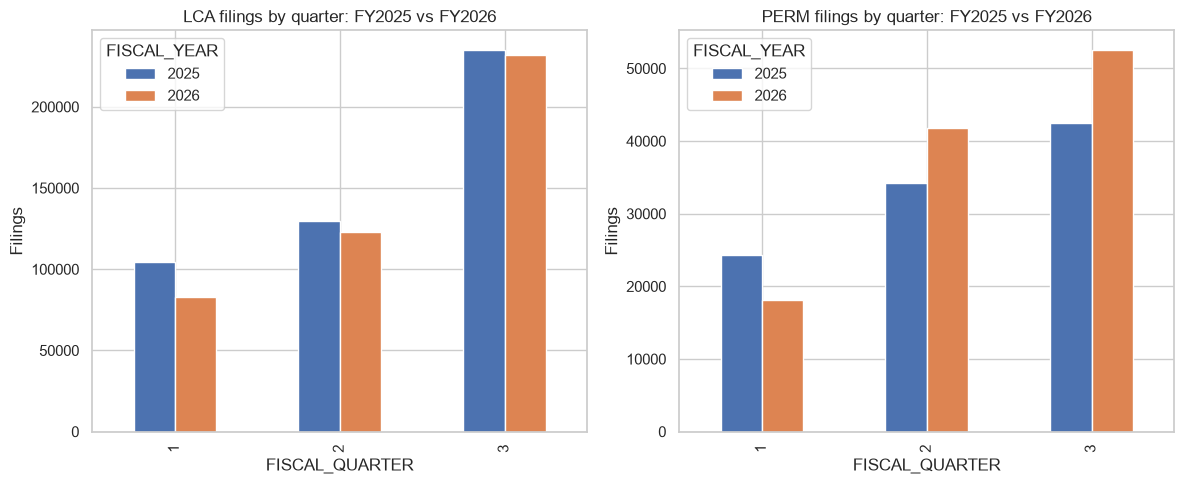

In [17]:
def yoy_by_quarter(df, label):
    g = df[df["FISCAL_QUARTER"] <= 3].groupby(["FISCAL_YEAR", "FISCAL_QUARTER"]).size().unstack(0, fill_value=0)
    print(f"\n{label} — filings by quarter, FY2025 vs FY2026 (Q1-Q3 only):")
    print(g)
    if 2025 in g.columns and 2026 in g.columns:
        pct_change = (g[2026].sum() / g[2025].sum() - 1) * 100
        print(f"FY2026 Q1-Q3 vs FY2025 Q1-Q3: {pct_change:+.1f}%")
    return g


lca_yoy = yoy_by_quarter(lca, "LCA (H-1B)")
perm_yoy = yoy_by_quarter(perm, "PERM")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lca_yoy.plot.bar(ax=axes[0])
axes[0].set_title("LCA filings by quarter: FY2025 vs FY2026")
axes[0].set_ylabel("Filings")
perm_yoy.plot.bar(ax=axes[1])
axes[1].set_title("PERM filings by quarter: FY2025 vs FY2026")
axes[1].set_ylabel("Filings")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_yoy_quarterly.png", dpi=150)
plt.show()

### Seasonality: does filing volume track the H-1B cap cycle?

The H-1B annual lottery registration window falls in March, with selected registrants filing
petitions (and the LCA that must precede them) mostly April-June. If that cycle drives LCA
volume, we'd expect a visible spring bump. PERM has no lottery, so no reason to expect the same
pattern — a useful contrast.

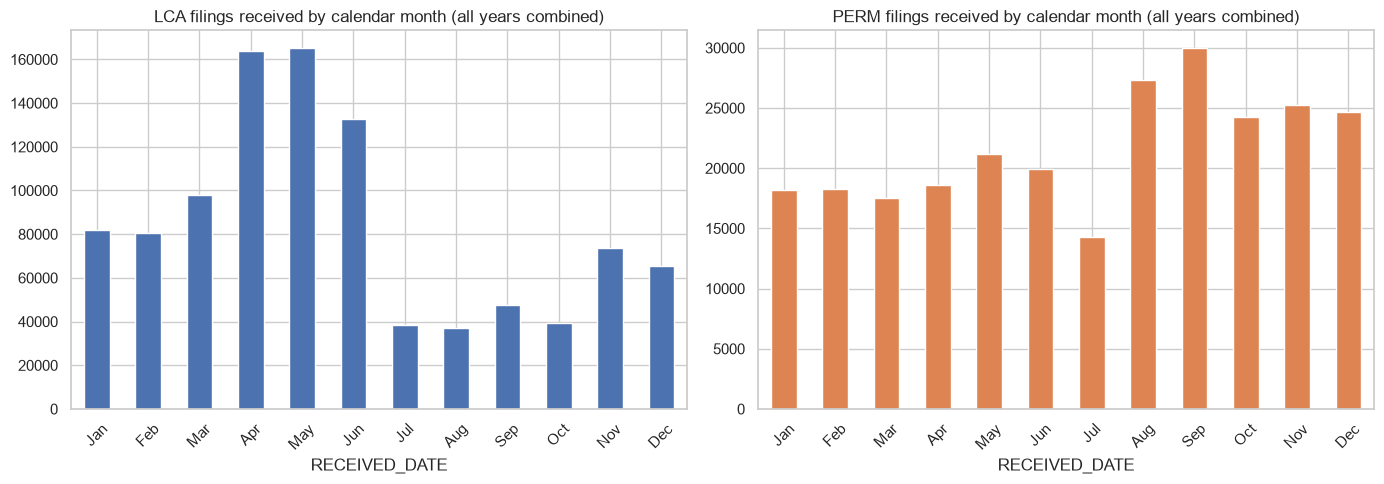

In [18]:
lca_by_month = lca["RECEIVED_DATE"].dt.month.value_counts().sort_index()
perm_by_month = perm["RECEIVED_DATE"].dt.month.value_counts().sort_index()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lca_by_month.reindex(range(1, 13), fill_value=0).plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_xticklabels(month_labels, rotation=45)
axes[0].set_title("LCA filings received by calendar month (all years combined)")
perm_by_month.reindex(range(1, 13), fill_value=0).plot.bar(ax=axes[1], color="#DD8452")
axes[1].set_xticklabels(month_labels, rotation=45)
axes[1].set_title("PERM filings received by calendar month (all years combined)")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_seasonality.png", dpi=150)
plt.show()

## Wages

Normalize everything to an annualized figure so hourly/weekly/monthly roles are comparable.

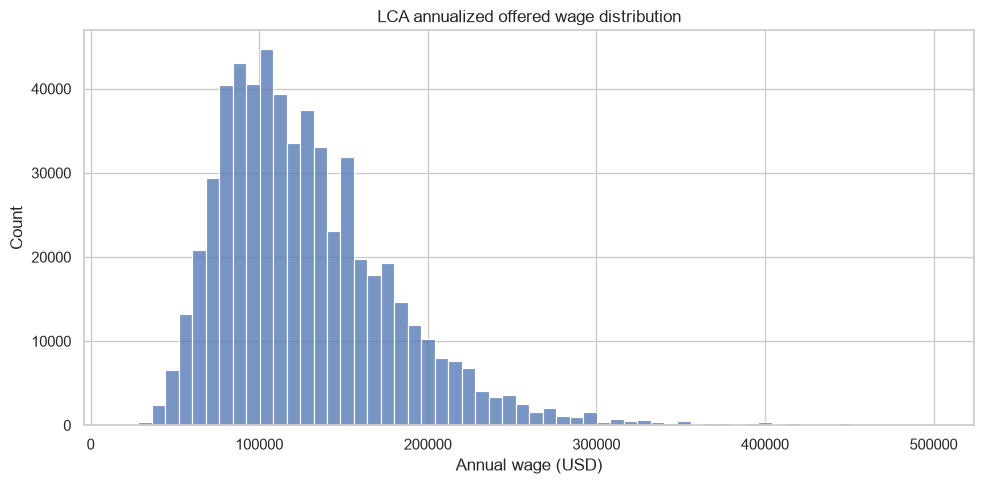

count    583291.000000
mean     129141.714393
std       53914.553622
min       20280.000000
25%       90002.000000
50%      119434.000000
75%      155605.000000
max      499999.920000
Name: ANNUAL_WAGE_FROM, dtype: float64


In [19]:
lca["ANNUAL_WAGE_FROM"] = annual_wage(lca["WAGE_RATE_OF_PAY_FROM"], lca["WAGE_UNIT_OF_PAY"])
lca_wage = lca[(lca["ANNUAL_WAGE_FROM"] > 20_000) & (lca["ANNUAL_WAGE_FROM"] < 500_000)]

fig, ax = plt.subplots()
sns.histplot(lca_wage["ANNUAL_WAGE_FROM"], bins=60, ax=ax, color="#4C72B0")
ax.set_title("LCA annualized offered wage distribution")
ax.set_xlabel("Annual wage (USD)")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_wage_distribution.png", dpi=150)
plt.show()

print(lca_wage["ANNUAL_WAGE_FROM"].describe())

## Geography: where are sponsoring employers located?

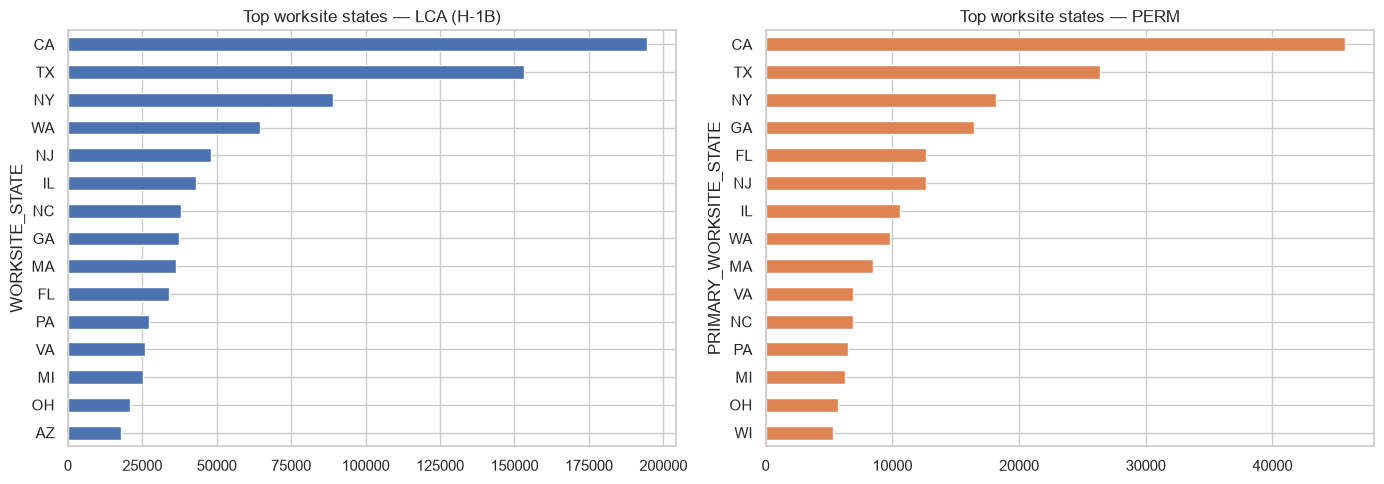

In [20]:
top_states_lca = lca["WORKSITE_STATE"].value_counts().head(15)
top_states_perm = perm["PRIMARY_WORKSITE_STATE"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_states_lca.sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Top worksite states — LCA (H-1B)")
top_states_perm.sort_values().plot.barh(ax=axes[1], color="#DD8452")
axes[1].set_title("Top worksite states — PERM")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_top_states.png", dpi=150)
plt.show()

## Top sponsoring employers (canonical names)

In [21]:
lca["EMPLOYER_CANONICAL"].value_counts().head(20)

EMPLOYER_CANONICAL
Amazon.com Services LLC                   29458
COGNIZANT TECHNOLOGY SOLUTIONS US CORP    16918
Google LLC                                16421
Ernst & Young U.S. LLP                    15846
Microsoft Corporation                     14461
Apple Inc.                                11999
Meta Platforms, Inc                       11908
TATA CONSULTANCY SERVICES LIMITED         10806
INFOSYS LIMITED                           10377
Deloitte Consulting LLP                    6919
WAL-MART ASSOCIATES, INC.                  6466
JPMorgan Chase & Co.                       6341
Amazon Web Services, Inc.                  6255
Tesla, Inc.                                5676
Amazon Development Center U.S., Inc.       5075
Intel Corporation                          4533
CAPGEMINI AMERICA INC                      4483
Accenture LLP                              4409
NVIDIA Corporation                         4356
HCL AMERICA INC                            4355
Name: count, dtype: i

In [22]:
perm["EMPLOYER_CANONICAL"].value_counts().head(20)

EMPLOYER_CANONICAL
Microsoft Corporation                  4840
Management Health Systems, LLC         2624
FPL Food, LLC                          2322
JCG Foods of Georgia, LLC              2159
Labor Guys, LLC                        2072
Consolidated Catfish Producers, LLC    2057
Stoughton Trailers, LLC                1590
WAL-MART ASSOCIATES, INC.              1564
Oracle America, Inc.                   1557
JPMORGAN CHASE & CO.                   1489
NVIDIA Corporation                     1461
South Georgia Pecan Company            1389
Intel Corporation                      1365
Salesforce, Inc.                       1290
APPLE INC.                             1286
Deloitte Consulting LLP                 993
FMR LLC                                 960
Cisco Systems, Inc.                     932
Case Farms Processing, Inc              893
MERIT LOGISTICS                         874
Name: count, dtype: int64

## Save lightweight summaries for reuse

These are small aggregate CSVs (not the raw data) so they're safe to commit and reuse
directly in the dashboard later.

In [23]:
lca["SOC_TITLE"].value_counts().rename("filings").to_csv(PROCESSED_DIR / "lca_top_occupations.csv")
perm["PWD_SOC_TITLE"].value_counts().rename("filings").to_csv(PROCESSED_DIR / "perm_top_occupations.csv")
lca["EMPLOYER_CANONICAL"].value_counts().rename("filings").head(200).to_csv(PROCESSED_DIR / "lca_top_employers.csv")
perm["EMPLOYER_CANONICAL"].value_counts().rename("filings").head(200).to_csv(PROCESSED_DIR / "perm_top_employers.csv")

print("Saved summary CSVs to", PROCESSED_DIR)

Saved summary CSVs to /Users/jaime/Local Documents/GitHub/h1b_analysis/data/processed


## Open questions heading into notebook 02

1. Neither file exposes a "minimum degree required" field — how do we approximate
   "MBA-reachable" roles from SOC code / job title alone? (see `src/mba_occupations.py`)
2. Which employers sponsor MBA-relevant roles specifically, not just tech roles in general?
3. Do certification/denial rates differ meaningfully by occupation tier or employer?
4. Where geographically do MBA-relevant sponsorships concentrate vs. the overall market?
5. What's the wage premium (or discount) for MBA-relevant roles vs. the broader population?
6. Employer names are now canonicalized for casing/punctuation/legal-suffix noise — but
   distinct legal subsidiaries of the same brand (Amazon Web Services vs Amazon.com Services
   LLC) still show up separately. Worth a manually-curated brand rollup for just the top ~50-100
   employers that matter most for the dashboard leaderboard.